# Extract Needed Variables from Observed Sea Level Data

This notebook performs the following steps:

1. **Load tide gauge sea level data**  
   Tide gauge data are stored as `.pkl` files, each containing a `pandas.Series` with a datetime index and a column `'SL'` representing sea level.

2. **Search and remove any outliers**  
   Search and remove outliers using a rolling time window and a threshold based on the window's median and standard deviation.
   
3. **Remove Sea Level Rise (SLR)**  
   Detrend the data by removing long-term trends using linear regression.

4. **Predict the tidal signal per tide gauge**  
   Use harmonic analysis to model the tidal component of the signal.

5. **Calculate the Non-tidal Residual**  
   Subtract the predicted tidal signal from the observed sea level to isolate residuals.

6. **Calculate the Skew-surge**  
   Estimate skew-surge values by analyzing deviations from the predicted tidal peaks.

The station metadata is provided in a `stations_info.csv` file, which contains station information such as name, longitude, and latitude.


## 1. Load data

First, we have to download the input data and unzip it. 

In [6]:
# !wget https://geoocean.unican.es/data/inputs-Extremes-TimeseriesClass.zip

# !unzip inputs-Extremes-TimeseriesClass.zip -d inputs/

In [2]:
import pandas as pd

# Load station info (names,lon,lat)
stations = pd.read_csv("inputs/stations_info.csv", usecols=["station", "lon", "lat"])
stations

,station,lon,lat
0,Huibertgat,6.398433,53.573748
1,Schiermonnikoog,6.202908,53.468935
2,Eemshaven,6.828392,53.448699
3,Nes,5.758907,53.429936
4,Lauwersoog,6.196952,53.408684
5,West_Terschelling,5.220026,53.363043
6,Vlieland_Haven,5.091456,53.296125
7,Harlingen,5.409342,53.175632
8,Oudeschild,4.850192,53.038833
9,Den_Helder,4.744990,52.964357


In [3]:
# Load sea level data per station in a list
SL = []
for i in range(len(stations)):
    sl_element = pd.read_pickle(f"inputs/GESLA_NLD/tide_gauge_{i}.pkl")
    # Append loaded data to lists
    SL.append(sl_element)

## 2. Search and remove any outliers

In [ ]:
from utils.GESLA_extract_variables import detect_outliers_window

all_outliers = [
    detect_outliers_window(series, deviation_threshold=3, window_size_days=2)
    for series in SL
]

[[],
 [],
 [],
 [],
 [],
 [],
 [],
 [23055],
 [],
 [],
 [1658685],
 [1763118],
 [1317687,
  1317688,
  1317689,
  1740152,
  1740153,
  1740154,
  1740155,
  2312054,
  2312055,
  2312056,
  2312063,
  2312064],
 [1553726, 1553727, 1553728],
 [],
 []]

## 3. Remove Sea Level Rise (SLR)

In [5]:
from utils.GESLA_extract_variables import detrend_series

trends = []
detrended_SL = []

for sl_element in SL:
    detrended, trend = detrend_series(sl_element)
    trends.append(trend)
    detrended_SL.append(detrended)

## 4. Predict the tidal signal per tide gauge

In [6]:
import utide

tides = []
coefs = []

for i, detrended_series in enumerate(detrended_SL):
    detrended_series.dropna(inplace=True)
    t = detrended_series.index

    # Solve for tidal coefficients
    coef = utide.solve(
        t,
        detrended_series,
        lat=stations["lat"][i],
        method="ols",
        nodal=True,
        trend=False,
        conf_int="MC",
    )

    # Reconstruct tidal signal
    reconstruction = utide.reconstruct(t, coef)
    tide = pd.Series(reconstruction.h, index=reconstruction.t_in)

    tides.append(tide)
    coefs.append(coef)

solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ..

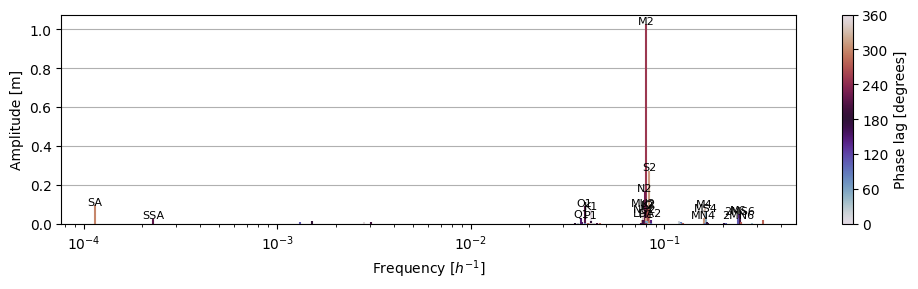

(<Figure size 1000x300 with 2 Axes>,
 <Axes: xlabel='Frequency [$h^{-1}$]', ylabel='Amplitude [m]'>)

In [7]:
from utils.GESLA_extract_variables import HarmonicAnalysis

# Usage without specifying efreq
ha = HarmonicAnalysis(coefs[0])  # first station
ha.plot_coefs()

## 5. Calculate the Non-tidal Residual

In [ ]:
## NTR = detrended SL - tides

NTR = [detrended - tide for detrended, tide in zip(detrended_SL, tides)]

## 6. Calculate the Skew Surge

To compute the **skew surge**, we follow these steps:

1. **Extract the predicted high water levels**  
   Use the *turning point method* (Haigh et al., 2016; Woodworth et al., 1991) to identify tidal high waters.

2. **Identify the nearest observed high water level**  
   Match each predicted high tide with the closest measured peak in the observed data.

3. **Calculate the skew surge**  
   Subtract the predicted high water from the observed high water:
   
<div align="center"><strong>Skew Surge = Observed High Water − Predicted High Water</strong></div>

In [12]:
from utils.GESLA_extract_variables import (
    extract_high_water_tides,
    find_measured_high_water,
)

high_water_tides = extract_high_water_tides(tides, min_hours_between=6)
high_water_measured = find_measured_high_water(
    detrended_SL, high_water_tides, time_window_hours=6
)

skew_surge = [
    measured - tide for measured, tide in zip(high_water_measured, high_water_tides)
]

## Save variables (optional)

In [14]:
import os

os.makedirs("outputs", exist_ok=True)
# os.makedirs("outputs/Processed_SL", exist_ok=True)
# os.makedirs("outputs/Tide", exist_ok=True)
os.makedirs("outputs/NTR", exist_ok=True)
os.makedirs("outputs/High_Water_Tide", exist_ok=True)
# os.makedirs("outputs/High_Water_Measured", exist_ok=True)
# os.makedirs("outputs/Skew_Surge", exist_ok=True)

for i, (
    detrended_element,
    tides_element,
    NTR_element,
    high_tide_element,
    high_meas_element,
    skew_element,
) in enumerate(
    zip(detrended_SL, tides, NTR, high_water_tides, high_water_measured, skew_surge)
):
    # detrended_element.to_pickle(f"outputs/Processed_SL/detrended_SL_{i}.pkl")
    # tides_element.to_pickle(f"outputs/Tide/tides_{i}.pkl")
    NTR_element.to_pickle(f"outputs/NTR/ntr_{i}.pkl")
    high_tide_element.to_pickle(f"outputs/High_Water_Tide/high_water_tide_{i}.pkl")
    # high_meas_element.to_pickle(f"outputs/High_Water_Measured/high_water_meas_{i}.pkl")
    # skew_element.to_pickle(f"outputs/Skew_Surge/skew_surge_{i}.pkl")